### О задании

В этом задании вам предстоит предсказывать год выпуска песни (**задача регрессии**) по некоторым звуковым признакам: [данные](https://archive.ics.uci.edu/ml/datasets/yearpredictionmsd). В ячейках ниже находится код для загрузки данных. Обратите внимание, что обучающая и тестовая выборки располагаются в одном файле, поэтому НЕ меняйте ячейку, в которой производится деление данных.

In [1]:
import random

import numpy as np
import pandas as pd
import torch
from torch import nn

In [2]:
df = pd.read_csv("data.txt.zip", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [3]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = 463715
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

## Задание 0. (0 баллов, но при невыполнении максимум за все задание &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Для самого первого бейзлайна обучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

In [4]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

In [5]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print("RMSE Ridge:", rmse_ridge)

y_const = np.full_like(y_test, fill_value=y_train.mean(), dtype=np.float64)
rmse_const = np.sqrt(mean_squared_error(y_test, y_const))
print("RMSE константный прогноз:", rmse_const)

RMSE Ridge: 9.510160711373398
RMSE константный прогноз: 10.85246390513634


## Задание 1. (максимум 10 баллов)

Реализуйте обучение и тестирование нейронной сети для предоставленного вам набора данных. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 9.00 $ &mdash; 4 балла
- $\text{RMSE} \le 8.90 $ &mdash; 6 баллов
- $\text{RMSE} \le 8.80 $ &mdash; 8 баллов
- $\text{RMSE} \le 8.75 $ &mdash; 10 баллов

Есть несколько правил, которых вам нужно придерживаться:

- Весь пайплайн обучения должен быть написан на PyTorch. При этом вы можете пользоваться другими библиотеками (`numpy`, `sklearn` и пр.), но только для обработки данных. То есть как угодно трансформировать данные и считать метрики с помощью этих библиотек можно, а импортировать модели из `sklearn` и выбивать с их помощью требуемое качество &mdash; нельзя. Также нельзя пользоваться библиотеками, для которых сам PyTorch является зависимостью.

- Мы никак не ограничиваем ваш выбор архитектуры модели, но скорее всего вам будет достаточно полносвязной нейронной сети.

- Для обучения запрещается использовать какие-либо иные данные, кроме обучающей выборки.

- Ансамблирование моделей запрещено.

### Полезные советы:

- Очень вряд ли, что у вас с первого раза получится выбить качество на 10 баллов, поэтому пробуйте разные архитектуры, оптимизаторы и значения гиперпараметров. В идеале при запуске каждого нового эксперимента вы должны менять что-то одно, чтобы точно знать, как этот фактор влияет на качество.

- Не забудьте, что для улучшения качества модели вам поможет **нормировка таргета**.

- Тот факт, что мы занимаемся глубинным обучением, не означает, что стоит забывать про приемы, использующиеся в классическом машинном обучении. Так что обязательно проводите исследовательский анализ данных, отрисовывайте нужные графики и не забывайте про масштабирование и подбор гиперпараметров.

- Вы наверняка столкнетесь с тем, что ваша нейронная сеть будет сильно переобучаться. Для нейросетей существуют специальные методы регуляризации, например, dropout ([статья](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)) и weight decay ([блогпост](https://towardsdatascience.com/weight-decay-l2-regularization-90a9e17713cd)). Они, разумеется, реализованы в PyTorch. Попробуйте поэкспериментировать с ними.

- Если вы чего-то не знаете, не гнушайтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению в целом и по PyTorch в частности. Но не забывайте, что за скатанный код без ссылки на источник придется ответить по всей строгости!

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так!

- Пользуйтесь утилитами, которые вам предоставляет PyTorch (например, Dataset и Dataloader). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

**ОБЯЗАТЕЛЬНО** рисуйте графики зависимости лосса/метрики на обучающей и тестовой выборках в зависимости от времени обучения. Если обучение занимает относительно небольшое число эпох, то лучше рисовать зависимость от номера шага обучения, если же эпох больше, то рисуйте зависимость по эпохам. Если проверяющий не увидит такого графика для вашей лучшей модели, то он в праве снизить баллы за задание.

**ВАЖНО!** Ваше решение должно быть воспроизводимым. Если это не так, то проверяющий имеет право снизить баллы за задание. Чтобы зафиксировать random seed, воспользуйтесь функцией из ячейки ниже.



In [6]:
def set_random_seed(seed=42):
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_random_seed(42)

Вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться следующими сигнатурами функций. Лучше всего, если вы проверите ваши предсказания ассертом: так вы убережете себя от разных косяков, например, что вектор предсказаний состоит из всего одного числа. В любом случае, внимательно следите за тем, для каких тензоров вы считаете метрику RMSE. При случайном или намеренном введении в заблуждение проверяющие очень сильно разозлятся.

In [7]:
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler 
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [10]:
class MusicDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [11]:
# нормализация признаков и таргета
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# создаём датасеты
train_set = MusicDataset(X_train_scaled, y_train_scaled)
test_set = MusicDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_set, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1024, shuffle=False)

In [12]:
import torch.nn as nn

class MusicNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


model = MusicNet(X_train.shape[1]).to(device)

In [13]:
import torch.optim as optim

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)

epochs = 10
steps_per_epoch = len(train_loader)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    total_steps=epochs * steps_per_epoch,
    pct_start=0.1,
    anneal_strategy='cos',
    final_div_factor=100
)

In [14]:
from sklearn.metrics import mean_squared_error
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import math

In [15]:
def train(model, optimizer, criterion, scheduler, train_loader, test_loader, scaler_y, epochs=40, device=device, clip=1.0):
    train_losses, val_rmses, train_rmses = [], [], []
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
           
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            optimizer.step()
            scheduler.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)

        model.eval()
        preds = []
        trues = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                out = model(X_batch).cpu().numpy()
                preds.append(out)
                trues.append(y_batch.numpy())
        preds = np.concatenate(preds, axis=0)
        trues = np.concatenate(trues, axis=0)

        preds_orig = scaler_y.inverse_transform(preds.reshape(-1,1)).flatten()
        trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).flatten()

        val_rmse = math.sqrt(mean_squared_error(trues_orig, preds_orig))
        val_rmses.append(val_rmse)

        train_rmses.append(None) 

        clear_output(wait=True)
        plt.plot(val_rmses, label='Val RMSE (orig scale)')
        plt.xlabel('Epoch')
        plt.ylabel('RMSE')
        plt.legend()
        plt.show()

        print(f"Epoch {epoch+1}/{epochs}, Train loss (scaled MSE): {train_loss:.6f}, Val RMSE (orig): {val_rmse:.4f}")

    return val_rmses

In [16]:
def test(model, scaler_y, test_loader, device=device):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch).cpu().numpy()
            preds.append(y_pred)
    preds = np.concatenate(preds, axis=0)
    preds = scaler_y.inverse_transform(preds.reshape(-1,1)).flatten()
    return preds


# чек размерности
y_pred_test = test(model, scaler_y, test_loader)
assert y_pred_test.shape[0] == y_test.shape[0]

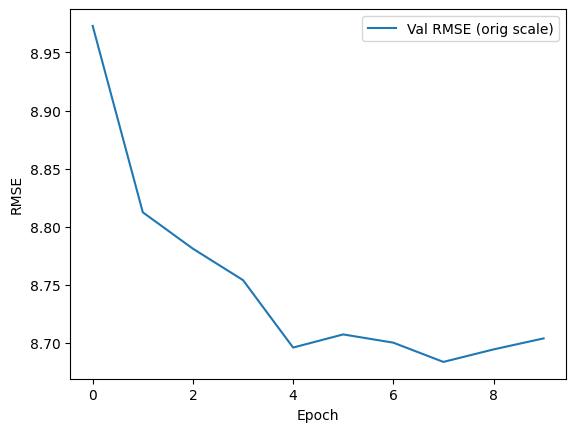

Epoch 10/10, Train loss (scaled MSE): 0.581283, Val RMSE (orig): 8.7039
Final Test RMSE: 8.70385519967526


In [17]:
val_rmses = train(model, optimizer, criterion, scheduler, train_loader, test_loader, scaler_y, epochs=epochs, device=device)
y_pred_test = test(model, scaler_y, test_loader, device=device)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("Final Test RMSE:", final_rmse)

Final Test RMSE: 8.70385519967526


## Задание 2. (0 баллов, но при невыполнении максимум за все задание &mdash; 0 баллов)

Напишите небольшой отчет о том, как вы добились полученного качества: какие средства использовали и какие эксперименты проводили. Подробно расскажите об архитектурах и значениях гиперпараметров, а также какие метрики на тесте они показывали. Чтобы отчет был зачтен, необходимо привести хотя бы 3 эксперимента.

что я меняла: 

1. добавляла слой и уменьшала дроп:

было: 
      


        #self.net = nn.Sequential(
            #nn.Linear(input_dim, 512),
            #nn.ReLU(),
            #nn.Dropout(0.3),
            #nn.Linear(512, 256),
            #nn.ReLU(),
            #nn.Dropout(0.2),
            #nn.Linear(256, 128),
            #nn.ReLU(),
            #nn.Linear(128, 1)
        #)

стало: 

        #self.net = nn.Sequential(
            #nn.Linear(input_dim, 512),
            #nn.ReLU(),
            #nn.Dropout(0.2),
            #nn.Linear(512, 256),
            #nn.ReLU(),
            #nn.Dropout(0.15),
            #nn.Linear(256, 128),
            #nn.ReLU(),
            #nn.Linear(128, 64),
            #nn.ReLU(),
            #nn.Linear(64, 1)
        #)

на этом же этапе добавила scheduler, уменьшающий learning rate в 2 раза каждые 5 эпох: 

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

еще увеличила число эпох с 10 до 30

после этих 3 преобразований rmse 10.93233101910249 стал rmse 10.849027289459706.

2. 

дальше: нормализовала данные через StandardScaler, стала прогонять через GPU для ускорения, добавила BatchNorm после линейных слоев, уменьшила Dropout до 0.15 и 0.12, увеличила эпохи до 40

rmse стал 9.09936098642801

3. 

дальше: дропнула эпохи с 40 до 10, понизила скорость обучения с 1e-3 до 3e-4, увеличила Dropout с 0.15 и 0.12 до 0.3 и 0.25

и rmse 9.09936098642801 стал rmse: 8.70385519967526

ура!